In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

TODO:
1) X - Save Models
2) train from script
3) Subset fragment lengths
4) explore variance of counts
5) Add jitter
6) add count head
7) Don't filter out duplicates in frag h5 creation
8) Only fit forward starts and reverse ends

In [2]:
import os

import pandas as pd
import pysam

from tqdm.notebook import tqdm
tqdm.pandas()

from fragmentomics_tools.dataframe import RegionDataFrame

In [3]:
FASTA_PATH = "/home/nboley/src/Ravel/data/repo_data_manifest/reference/GRCh38/GRCh38.p12.genome.fa.gz"

In [418]:
import itertools
from typing import Optional # , Dict, Type, Union, Tuple, List

from typing import Dict, Optional, List, Set, Type, Union

import numpy
import pandas
import torch
from torch import Tensor
import torch.optim as optim


import os
import torch
from torch import optim, nn, utils, Tensor
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
import lightning as L
from fragmentomics_tools.sequence import one_hot_encode_sequences


import matplotlib.pyplot as plt

from fragmentomics_tools.dataframe import DataFrameBase
from fragmentomics_tools.region import Region

# from ravel.learn.functional_genomics.losses import MultinomialNLLLoss

from scipy.stats import multinomial
from scipy.special import softmax

In [302]:
def train(model, sdf, train_rdf, val_rdf, max_epochs=10):
    import warnings
    warnings.filterwarnings("ignore", ".*Received a 3D input to dropout2d*")
    
    train_dataset = FragmentEndpointsDataset(train_rdf, sdf, model)
    val_dataset = FragmentEndpointsDataset(val_rdf, sdf, model)
    
    val_loader = utils.data.DataLoader(val_dataset, batch_size=64)
    train_loader = utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

    trainer = L.Trainer(max_epochs=max_epochs)
    trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)

    return model

In [303]:
from data import HematopoieticGeneExpression
hge_raw = HematopoieticGeneExpression.load()

In [304]:
from lib import load_ibd_sample_df
sdf = load_ibd_sample_df() # .query("sample_id == 'RD-56170'")
sample_ids = sdf.sample_id.tolist()
train_rdf = hge_raw.query("expression < 0.01").head(2600) # 2600)
val_rdf = hge_raw.query("expression < 0.01").tail(200)

In [381]:
def train_all():
    for i, sample_id in enumerate(sample_ids):
        model = BackgroundModelModule(num_residual_layers=2, output_columns=['fwd_start_counts', 'bkwd_stop_counts'], loss="negative_binomial")
        model = train(model, sdf.query("sample_id == @sample_id"), train_rdf, val_rdf, max_epochs=1)
        # model.save(f'/scratch/karius/bias_correction_model/{sample_id}.two_residual.negative_binomial.2.res')
        model.save('/scratch/karius/bias_correction_model/new_loss_test.res')
        print(f"Finished {sample_id} ({i}/{len(sample_ids)})")
        break

In [382]:
train_all()

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 680/680 [00:00<00:00, 1185.22it/s]
INFO: Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO	2024-04-01 15:18:47,853	Trainer will use only 1 of 3 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=3)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
INFO: GPU available: True (cuda), used: True
INFO	2024-04-01 15:18:47,870	GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO	2024-04-01 15:18:47,871	TPU available: False, using: 0 TPU cores
INFO: IPU available: False, using: 0 IPU

Sanity Checking: |                                                                                            …

WARNING	2024-04-01 15:18:47,895	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.

WARNING	2024-04-01 15:18:48,824	/home/nboley/miniconda3/envs/fragmentomics_tools_dev/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.



Training: |                                                                                                   …

Validation: |                                                                                                 …

INFO: `Trainer.fit` stopped: `max_epochs=1` reached.
INFO	2024-04-01 15:21:46,195	`Trainer.fit` stopped: `max_epochs=1` reached.


Finished RD-56170 (0/18)


In [307]:
val_dataset = FragmentEndpointsDataset(val_rdf, sdf.query("sample_id == @sample_id"), model)

100%|█████████████████████████████████████████████████████████████████████████████████████████████| 680/680 [00:00<00:00, 1222.55it/s]


In [384]:
model = BackgroundModelModule.load('/scratch/karius/bias_correction_model/new_loss_test.res').cpu()

array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>],
       [<Axes: title={'center': '2'}>, <Axes: title={'center': '3'}>]],
      dtype=object)

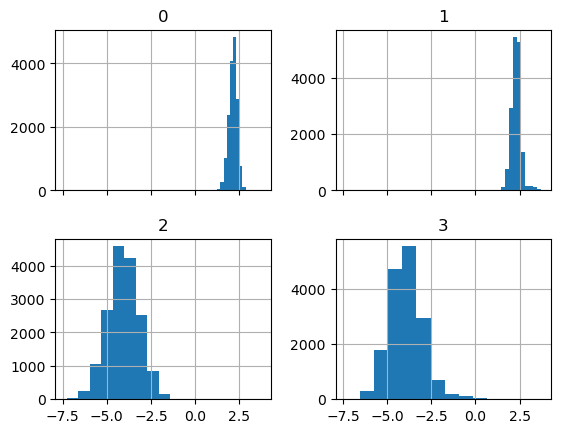

In [385]:
pd.DataFrame(model.model(val_dataset[0][0].cpu()).cpu().detach()).T.hist(sharex=True)

In [386]:
# model.save('/scratch/karius/bias_correction_model/RD-56170.two_residual.negative_binomial.1.res')
#model = BackgroundModelModule.load('/scratch/karius/bias_correction_model/merged.two_residual.negative_binomial.5.res').cpu()

In [387]:
from torch.distributions.utils import logits_to_probs, probs_to_logits
from scipy.stats import nbinom
from fragmentomics_tools.fragment_array import RegionFragmentArray, merge_fragment_arrays

class BackgroundModelPredictionsDataFrame(DataFrameBase):
    _metadata = ["region"]

    def __init__(self, data, *args, **kwargs):
        super().__init__(data, *args, **kwargs)
        if isinstance(data, pandas.core.internals.BlockManager):
            return

    def make_tracks(self, sharey=False, smooth=False):
        base_columns = [c for c in self.columns if not c.endswith("_hat")]
        tracks = Tracks()
        tracks.append(GeneTrack("/scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed.gz", self.region))

        if sharey:
            ylim = (0, int(self.max().max()*1.1))
        else:
            ylim = None
        for base_column in sorted(base_columns):
            track = VectorTrack(self[base_column], self.region, name=f"Observed - {base_column}", color='black', alpha=0.7, ylim=ylim, smooth=smooth) + \
                    VectorTrack(self[base_column + "_hat"], self.region, name=f"Predicted - {base_column}", color='purple', alpha=0.5, ylim=ylim, smooth=smooth) 
            if base_column + "_hat_upper_bnd" in self:
                track += VectorTrack(self[base_column + "_hat_upper_bnd"], self.region, name=f"Predicted - {base_column}", color='orange', alpha=0.5, ylim=ylim, smooth=smooth) 
            track.name = base_column
            tracks.append(track)
    
        tracks.append(BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/hg38-repeats.sorted.bed.gz", self.region))
        tracks.append(BedTrack("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", self.region))
    
        return tracks

def is_count_column(column):
    return not column.endswith("_hat")

def count_columns(columns):
    return tuple([c for c in columns if is_count_column(c)])

def predict_region(self, region, prbs=True):
    if self.model_params['loss'] == 'multinomial':
        columns = [x + "_hat" for x in self.output_columns]
    elif self.model_params['loss'] == 'negative_binomial':
        columns = [x + "_hat_logits" for x in self.output_columns] + [x + "_hat_total_count" for x in self.output_columns]
    elif self.model_params['loss'] == 'negative_binomial_fixed_total_count':
        columns = [x + "_hat_logits" for x in self.output_columns]
    else:
        raise ValueError(f"Unrecognized loss '{self.loss_fn}'")
    
    output_length = region.length
    input_length = self.calc_input_region_size(output_length)
    with pysam.Fastafile(FASTA_PATH) as fasta:
        seq = region.resize(input_length).get_sequence(fasta).decode()
    one_hot_seq = one_hot_encode_sequences([seq.encode(),])[0, :, :].T
    one_hot_seq = torch.Tensor(one_hot_seq)[None, :]
    pred = self.model(one_hot_seq).cpu().detach().numpy()[0].squeeze().astype("float64")
    if self.model_params['loss'] == 'negative_binomial':
        for i, column in enumerate(columns):
            if column.endswith("_hat_total_count"):
                pred[i] = self.loss_fn._transform_counts(torch.Tensor(pred[i])).numpy()
    
    if prbs:
        if self.model_params['loss'] == 'multinomial': 
            pred = softmax(pred, axis=1)
        elif self.model_params['loss'] == 'negative_binomial':
            columns = [x + "_hat" for x in self.output_columns]
            new_pred = []
            for column_i in range(len(self.output_columns)):
                logits = pred[column_i]
                total_count = pred[column_i + len(self.output_columns)]
                #new_pred.append((total_count * torch.exp(torch.tensor(logits)).numpy()))
                dist = nbinom(n=total_count, p=1-logits_to_probs(torch.Tensor(logits), is_binary=True))
                new_pred.append(dist.mean())
                # new_pred.append(dist.ppf(0.99))
            # pred = softmax(numpy.vstack(new_pred), axis=1)
            pred = new_pred # softmax(new_pred, axis=1)
        elif self.model_params['loss'] == 'negative_binomial_fixed_total_count':
            columns = [x + "_hat" for x in self.output_columns]
            new_pred = []
            for column_i in range(len(self.output_columns)):
                logits = pred[column_i]
                total_count = self.loss_fn.total_count
                dist = nbinom(n=total_count, p=1-logits_to_probs(torch.Tensor(logits), is_binary=True))
                new_pred.append(dist.mean())
            pred = new_pred # softmax(new_pred, axis=1)
        else:
            assert False, "UNREACHABLE"

    rv = pd.DataFrame(pred).T.rename(columns=dict(zip(range(4), columns)))
    return rv

def predict_from_region_fragment_array(self, rfa, prbs=True):
    targets = pd.DataFrame(FragmentEndpointsDataset.get_targets_from_region_fragment_array(rfa, self.output_columns).cpu().detach().T).rename(columns=dict(enumerate(self.output_columns)))
    pred = predict_region(self, rfa.region, prbs=prbs)
    #pred = (pred * (targets.max().values/pred.max().values))
    #pred = (pred * (targets.sum().values))
    return BackgroundModelPredictionsDataFrame(pd.concat([targets, pred], axis=1), region=rfa.region)

def predict_for_gene(self, gene_name, prbs=True):
    sub_df = hge_raw.query("gene_name == @gene_name")
    rfa = merge_fragment_arrays(SampleAndRegionDataFrame.init_from_rdf_and_sdf(sub_df, sdf).attach_fragment_arrays().fragment_array)
    return predict_from_region_fragment_array(self, rfa.subset_fragment_lengths(40, 60), prbs=prbs)

def plot_gene(model, gene_name):
    pred_df = predict_for_gene(model, gene_name, prbs=True)
    # scale the counts
    sums_series = pred_df.max()
    count_columns = [c for c in sums_series.index]
    # scale = [(sums_series[c[:-4]]/(sums_series[c].min()) if not is_count_column(c) else 1) for c in sums_series.index]
    scale = 1 # [(sums_series[c[:-4]].max()/(sums_series[c].max()) if not is_count_column(c) else 1) for c in sums_series.index]
    pred_df = pred_df*np.array(scale)
    pred_df.make_tracks(sharey=False, smooth=False).plot(title=gene_name)
    print(pred_df.sum().head(4))

def predict_for_genes(model, gene_names):
    rv = []
    for gene_name in gene_names:
        _ = predict_for_gene(model, gene_name, prbs=True)
        p = _[[x + "_hat" for x in count_columns(_.columns)]]
        p = p.sum() # /np.exp(p).sum().sum()
        c = _[list(count_columns(_.columns))]
        c = c.sum() # /c.sum().sum()
        # _ = (c - p.values)
        _ = pd.concat([c, p])
        _.name = gene_name
        rv.append(_)
    
    return pd.concat(rv, axis=1)

In [388]:
# sample_id = "RD-56170"
# model = BackgroundModelModule.load(f'/scratch/karius/bias_correction_model/{sample_id}.two_residual.negative_binomial.2.res').cpu()
model = BackgroundModelModule.load('/scratch/karius/bias_correction_model/new_loss_test.res').cpu()

In [389]:
model.model_params

{'loss': 'negative_binomial',
 'dropout': 0.15,
 'output_columns': ['fwd_start_counts', 'bkwd_stop_counts'],
 'input_channels': 4,
 'num_residual_layers': 2,
 'n_kernels': 512,
 'kernel_size': 32}

In [390]:
from scipy.stats import multinomial

def build_dist(self, pred):
    rv = []
    for i in range(len(self.output_columns)):
        if model.model_params['loss'] == 'negative_binomial':
            n, p = model.loss_fn.to_natural_param(pred[i], pred[i+2])
            dist = nbinom(n=n, p=p)
        elif model.model_params['loss'] == 'negative_binomial_old':
            ps = 1-logits_to_probs(torch.Tensor(pred[i]), is_binary=True)
            total_counts = model.loss_fn._transform_counts(torch.Tensor(pred[i+2]))
            dist = nbinom(n=total_counts, p=ps)
        elif model.model_params['loss'] == 'negative_binomial_fixed_total_count':
            ps = 1-logits_to_probs(torch.Tensor(pred[i]), is_binary=True)
            total_counts = model.loss_fn.total_count
            dist = nbinom(n=total_counts, p=ps)
        elif model.model_params['loss'] == 'multinomial':
            dist = multinomial(n=1, p=softmax(pred[i]))
        else:
            raise ValueError(f"Unrecognized loss '{model.model_params['loss']}'")
        rv.append(dist)
    return rv

def predict_from_rdf(self, rdf):
    rdf = rdf.resize_regions(self.calc_input_region_size(rdf.region_lengths))
    seq = rdf.get_one_hot_encoded_sequence(FASTA_PATH, verbose=True)

    self.cuda()
    self.eval()
    pred = seq.progress_apply(lambda x: self.model(torch.Tensor(x).cuda()).cpu().detach().numpy())
    dists = [build_dist(self, x) for x in tqdm(pred)]

    return pd.DataFrame(dists, columns=[x + "_dist" for x in model.output_columns], index=rdf.index)

In [391]:
def calc_stats(record):
    base_columns = [c for c in record.index.tolist() if c.endswith("_counts")]

    all_counts = [record[c] for c in base_columns]
    dists = [record[c + "_dist"] for c in base_columns]

    rv = {}
    for c, counts, dist in zip(base_columns, all_counts, dists):
        rv['gene_id'] = record.gene_id
        rv['gene_name'] = record.gene_name
        rv[c + "_count"] = counts.sum()
        rv[c + "_pred_count"] = dist.mean().sum()
        rv[c + "_l1_loss"] = np.abs(dist.mean() - counts).mean()
        rv[c + "_frac_over_95_conf"] = (counts > dist.ppf(0.95)).mean()
        # rv[c + "_frac_over_99_conf"] = (counts > dist.ppf(0.99)).mean()
    return pd.Series(rv)

def make_tracks(record, sharey=False, smooth=False, max_scale=False):
    region = Region(record.contig, record.start, record.stop, strand=record.strand)
    base_columns = [c for c in record.index.tolist() if c.endswith("_counts")]
    tracks = Tracks()
    tracks.append(GeneTrack("/scratch/karius/annotation/gencode/gencode.v45.basic.annotation.bed.gz", region))

    all_counts = [record[c] for c in base_columns]
    dists = [record[c + "_dist"] for c in base_columns]

    if sharey:
        ylim = (0, int(self.max().max()*1.1))
    else:
        ylim = None

    for base_column, counts, dist in zip(base_columns, all_counts, dists):
        if max_scale:
            scale = (counts.max()/dist.mean().max())
        else:
            scale = 1
        track = VectorTrack(counts, region, name=f"Observed - {base_column}", color='black', alpha=0.7, ylim=ylim, smooth=smooth) + \
                VectorTrack(scale*dist.mean(), region, name=f"Predicted - {base_column}", color='purple', alpha=0.5, ylim=ylim, smooth=smooth) + \
                VectorTrack(scale*dist.ppf(0.95), region, name=f"Predicted - {base_column}", color='orange', alpha=0.5, ylim=ylim, smooth=smooth)
            

        track.name = base_column
        tracks.append(track)

    tracks.append(BedTrack("/home/nboley/src/Ravel/data/repo_data_manifest/annotations/GRCh38_extras/hg38-repeats.sorted.bed.gz", region))
    tracks.append(BedTrack("/scratch/karius/annotation/mappability.simple_repeats.sorted.bed.gz", region))

    return tracks

def build_dists_and_counts(self, sdf, rdf):
    print("Building fragment arrays (1/5)")
    srdf = SampleAndRegionDataFrame.init_from_rdf_and_sdf(rdf, sdf).attach_fragment_arrays(num_cores=32)
    print("Merging fragment arrays (2/5)")
    merged_fas = srdf.groupby("gene_id").progress_apply(lambda x: merge_fragment_arrays(x.fragment_array.tolist())).rename('fragment_array')
    print("Predicting dists (3/5)")
    pred_dists = predict_from_rdf(model, rdf.set_index('gene_id'))

    print("Building observed arrays (4/5)")
    pred_columns = [c[:-5] for c in pred_dists.columns]
    obs_counts = merged_fas.progress_apply(lambda x: pd.Series(list(FragmentEndpointsDataset.get_targets_from_region_fragment_array(x, pred_columns).cpu().detach().numpy())))
    obs_counts = pd.DataFrame(obs_counts).rename(columns=dict(enumerate(pred_columns)))

    print("Merging Results (5/5)")
    return rdf.set_index('gene_id').join(obs_counts.join(pred_dists, how='inner')).reset_index()

In [392]:
marker_genes = pd.read_table("/scratch/karius/reference/markers.immune_vs_epithelial.tsv", sep=" ")
up_marker_genes = marker_genes.query("p_val_adj < 0.01 and avg_log2FC < -3").assign(direction='up_in_colon')
down_marker_genes = marker_genes.query("p_val_adj < 0.01 and avg_log2FC > 7").assign(direction='down_in_colon')
marker_genes = pd.concat([up_marker_genes, down_marker_genes])
test_rdf = hge_raw.set_index("gene_name").join(marker_genes, how='inner').reset_index().query("gene_name not in @train_rdf.gene_name.tolist() and direction == 'up_in_colon' and expression < 0.1").reset_index(drop=True)
# marker_genes = pd.DataFrame(scores).set_index("gene_name").join(marker_genes, how='inner').reset_index()

In [393]:
# model.save('/scratch/karius/bias_correction_model/RD-56170.two_residual.multinomial.1.res')

In [410]:
%%time
sample_id = sample_ids[0]
#model = model.load(f'/scratch/karius/bias_correction_model/{sample_id}.two_residual.negative_binomial.2.res').cpu()
model = BackgroundModelModule.load("/scratch/karius/bias_correction_model/new_loss_test.res").cpu()
sdf = load_ibd_sample_df()
rdf = hge_raw.query("expression < 0.01")
# sdf.query("sample_id == @sample_id")
tmp = build_dists_and_counts(model, sdf.query("sample_id == @sample_id"), test_rdf) # .query("sample_id == @sample_id")
# tmp = build_dists_and_counts(model, sdf, test_rdf)

Building fragment arrays (1/5)


100%|████████████████████████████████████████████████████████████████████████████████████████████████| 49/49 [00:00<00:00, 573.39it/s]

Merging fragment arrays (2/5)


  0%|          | 0/49 [00:00<?, ?it/s]

Predicting dists (3/5)


...

  0%|          | 0/49 [00:00<?, ?it/s]

  0%|          | 0/49 [00:00<?, ?it/s]

Building observed arrays (4/5)


  0%|          | 0/49 [00:00<?, ?it/s]

Merging Results (5/5)
CPU times: user 9.5 s, sys: 165 ms, total: 9.67 s
Wall time: 2.45 s


In [411]:
stats = pd.DataFrame(tmp).progress_apply(calc_stats, axis=1)

  0%|          | 0/49 [00:00<?, ?it/s]

In [412]:
stats

,gene_id,gene_name,fwd_start_counts_count,fwd_start_counts_pred_count,fwd_start_counts_l1_loss,fwd_start_counts_frac_over_95_conf,bkwd_stop_counts_count,bkwd_stop_counts_pred_count,bkwd_stop_counts_l1_loss,bkwd_stop_counts_frac_over_95_conf
0,ENSG00000131620,ANO1,5928.0,3306.515622,0.050583,0.007317,4865.0,4192.701715,0.049695,0.006231
1,ENSG00000242173,ARHGDIG,95.0,21.663927,0.047372,0.010335,70.0,48.032432,0.047965,0.007028
2,ENSG00000118322,ATP10B,3360.0,2094.295918,0.044135,0.006224,3446.0,2640.631914,0.049219,0.006494
3,ENSG00000198488,B3GNT6,173.0,103.010342,0.036147,0.005149,262.0,556.175302,0.102918,0.006601
4,ENSG00000139044,B4GALNT3,4189.0,2098.594121,0.058064,0.008323,3613.0,2813.209160,0.058396,0.006604
5,ENSG00000039987,BEST2,195.0,104.903169,0.043926,0.008055,220.0,158.427762,0.055386,0.006563
6,ENSG00000123838,C4BPA,957.0,630.119752,0.038649,0.005425,1196.0,933.669788,0.051682,0.006677
7,ENSG00000076826,CAMSAP3,1397.0,852.104568,0.093516,0.010427,405.0,452.411454,0.037504,0.004813
8,ENSG00000135773,CAPN9,1506.0,996.739983,0.045489,0.006637,1833.0,1265.368701,0.054849,0.006895
9,ENSG00000100065,CARD10,704.0,379.394095,0.056690,0.008357,393.0,550.725335,0.047854,0.004791


array([[1.        , 0.72677855],
       [0.72677855, 1.        ]])

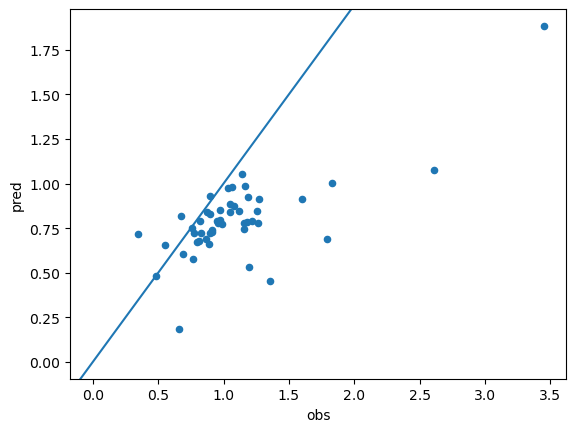

In [416]:
obs = stats.fwd_start_counts_count/stats.bkwd_stop_counts_count
pred = stats.fwd_start_counts_pred_count/stats.bkwd_stop_counts_pred_count
df = pd.DataFrame(dict(obs=obs, pred=pred), index=stats.index)
ax = df.plot.scatter(x='obs', y='pred')
ax.axline((0,0), slope=1)
np.corrcoef(df.T)

In [414]:
df.sort_values('obs')

,obs,pred
38,0.342105,0.719197
15,0.479612,0.479498
44,0.552058,0.653757
3,0.660305,0.185212
39,0.675000,0.819664
31,0.690316,0.605061
28,0.757875,0.749608
10,0.764319,0.578046
45,0.777429,0.724110
6,0.800167,0.674885


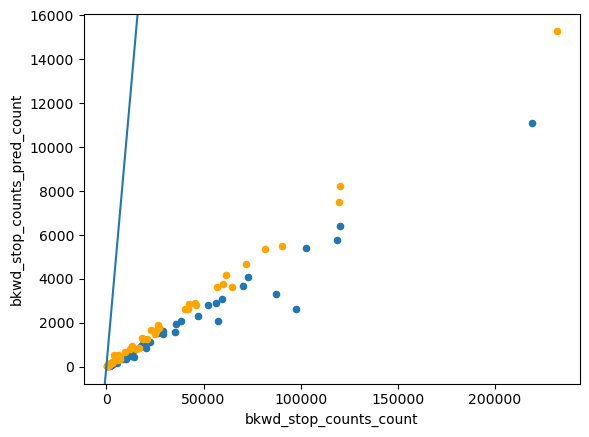

In [399]:
ax = stats.set_index("gene_name").plot.scatter(x='fwd_start_counts_count', y='fwd_start_counts_pred_count') # , xlim=(0, 20000), ylim=(0, 20000))
stats.set_index("gene_name").plot.scatter(x='bkwd_stop_counts_count', y='bkwd_stop_counts_pred_count', color='orange', ax=ax) # , xlim=(0, 20000), ylim=(0, 20000))
ax.axline((0,0), slope=1)

array([[<Axes: title={'center': 'fwd_start_counts_frac_over_95_conf'}>,
        <Axes: title={'center': 'bkwd_stop_counts_frac_over_95_conf'}>]],
      dtype=object)

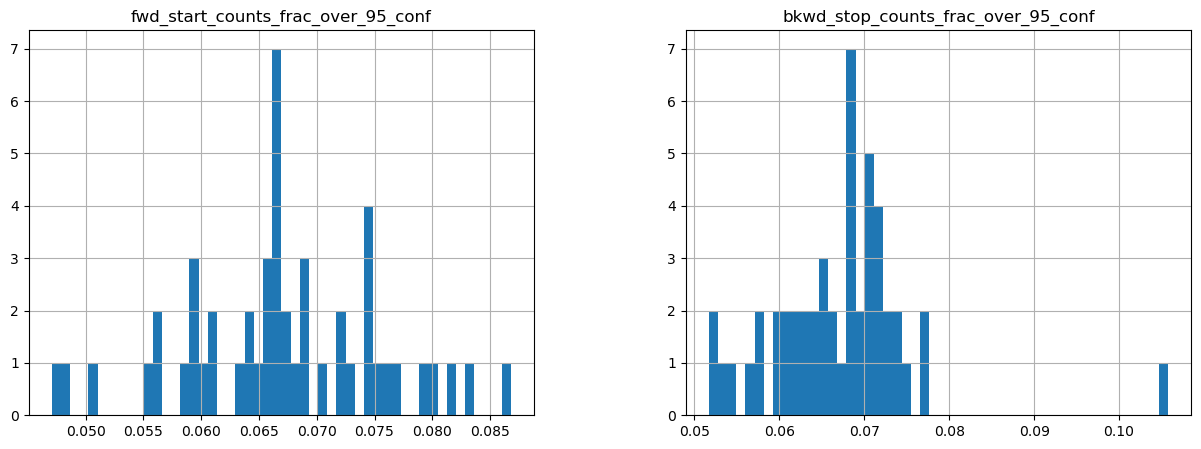

In [400]:
stats[['fwd_start_counts_frac_over_95_conf', 'bkwd_stop_counts_frac_over_95_conf']].hist(bins=50, figsize=(15, 5))

(<Figure size 2500x1000 with 5 Axes>,
 [<Axes: >,
  <Axes: title={'center': 'fwd_start_counts'}>,
  <Axes: title={'center': 'bkwd_stop_counts'}>,
  <Axes: >,
  <Axes: xlabel='chr19'>])

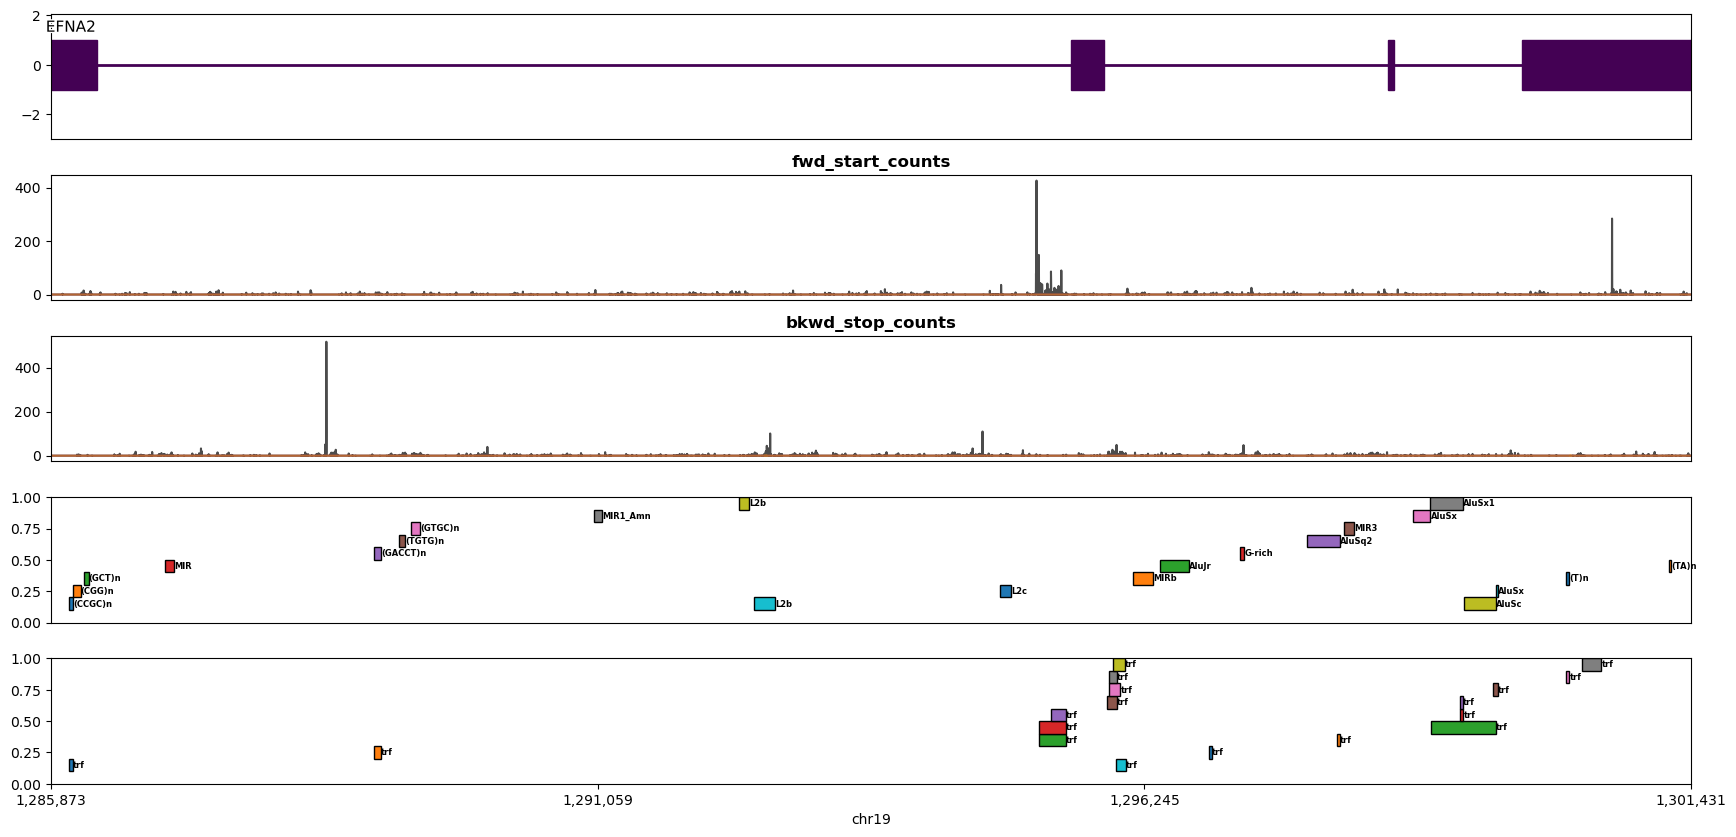

In [401]:
make_tracks(tmp.iloc[13], max_scale=False).plot()

In [402]:
import statsmodels.formula.api as smf

In [403]:
def initial_dist(counts):
    nbdata = pd.DataFrame({"nbdata": counts})
    nbfit = smf.negativebinomial("nbdata ~ 1", data=nbdata).fit_regularized()
    n, p = convert_params(nbdata.values.mean(), nbfit.params[1])
    return nbinom(n=n, p=p)

In [404]:
def qc_dist(data):
    dist = initial_dist(data)
    print(dist.kwds)
    print(dist.mean(), data.mean())
    print(dist.std(), data.std())
    pred = pd.DataFrame(dist.rvs(len(tmp.iloc[0].fwd_start_counts))).value_counts().rename('pred')
    obs = pd.DataFrame(tmp.iloc[0].fwd_start_counts.astype(int)).value_counts().rename("obs")# , obs=tmp.iloc[0].fwd_start_counts)).value_counts()
    return pd.DataFrame(obs).join(pred).fillna(0).sort_index() # .plot.scatter(x='obs', y='pred')

In [405]:
np.log(0.1)

-2.3025850929940455

In [406]:
qc_dist(data = tmp.iloc[10].fwd_start_counts).head(50)

WARNING	2024-04-01 15:24:10,823	/tmp/ipykernel_2477629/2653395590.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  n, p = convert_params(nbdata.values.mean(), nbfit.params[1])



Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3564741484959005
            Iterations: 19
            Function evaluations: 19
            Gradient evaluations: 19
{'n': 0.023061340202460073, 'p': 0.08028153964565375}
0.2641944885253907 0.2641945
1.8140699539962768 1.5626029


,obs,pred
0,,
0,165142,167554.0
1,2704,3555.0
2,1848,1694.0
3,1455,1074.0
4,1188,738.0
5,902,557.0
6,776,385.0
7,591,314.0
8,548,277.0


array([[<Axes: title={'center': 'p'}>, <Axes: title={'center': 'n'}>]],
      dtype=object)

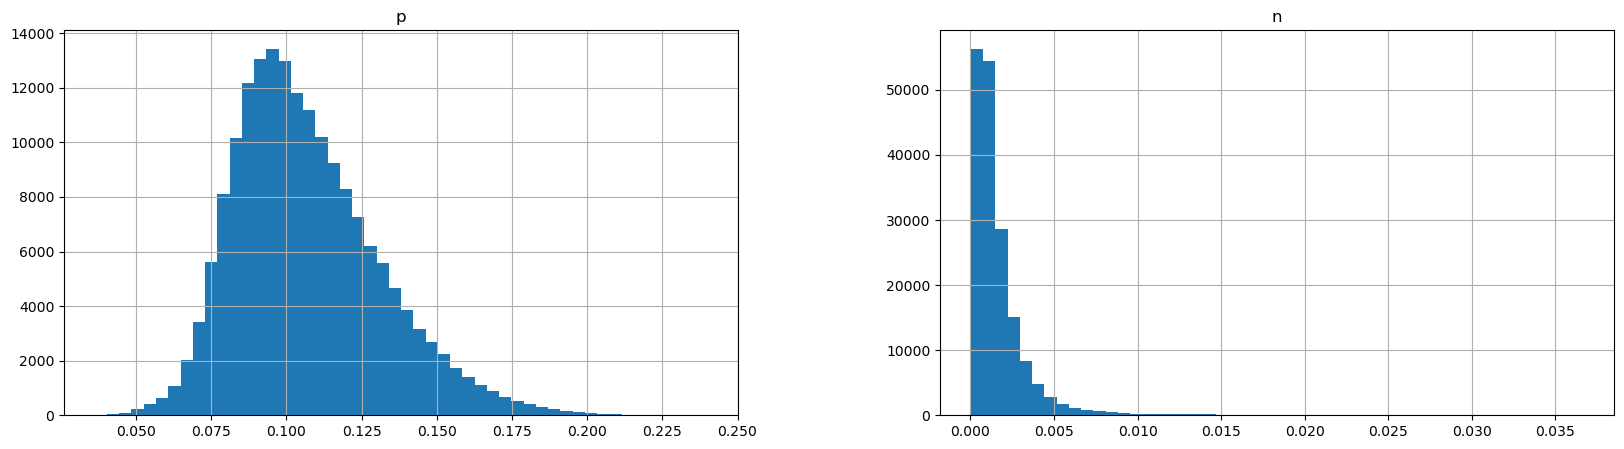

In [407]:
dist = tmp.iloc[0].fwd_start_counts_dist
pd.DataFrame(dict(p=dist.kwds['p'], n=dist.kwds['n'])).hist(figsize=(20, 5), bins=50)